In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/dataset_rent.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     100 non-null    int64  
 1   tamanho_m2             100 non-null    float64
 2   n_quartos              100 non-null    int64  
 3   idade_casa             100 non-null    float64
 4   garagem                100 non-null    int64  
 5   localizacao_Periferia  100 non-null    bool   
 6   localizacao_Subúrbio   100 non-null    bool   
 7   valor_aluguel          100 non-null    float64
dtypes: bool(2), float64(3), int64(3)
memory usage: 5.0 KB


In [4]:
df.isna().sum()

id                       0
tamanho_m2               0
n_quartos                0
idade_casa               0
garagem                  0
localizacao_Periferia    0
localizacao_Subúrbio     0
valor_aluguel            0
dtype: int64

In [5]:
df.head(5)

,id,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel
0,1,106.181018,1,36.760806,0,True,False,1767.122088
1,2,192.607146,4,10.453581,1,True,False,3278.742397
2,3,159.799091,5,27.072399,1,True,False,2953.899737
3,4,139.798773,4,34.789220,1,False,True,2514.717108
4,5,73.402796,5,11.427501,0,False,True,1942.164396


In [6]:
df.drop(columns=['id'], inplace=True)

In [7]:
df.head(5)

,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel
0,106.181018,1,36.760806,0,True,False,1767.122088
1,192.607146,4,10.453581,1,True,False,3278.742397
2,159.799091,5,27.072399,1,True,False,2953.899737
3,139.798773,4,34.789220,1,False,True,2514.717108
4,73.402796,5,11.427501,0,False,True,1942.164396


In [8]:
df.describe()

,tamanho_m2,n_quartos,idade_casa,garagem,valor_aluguel
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,120.527112,2.910000,25.794810,0.520000,2112.819084
std,44.623412,1.400541,14.348628,0.502117,514.314100
min,50.828318,1.000000,0.259243,0.000000,1192.728727
25%,78.980114,1.750000,13.969405,0.000000,1694.633091
50%,119.621368,3.000000,24.827177,1.000000,2069.395680
75%,159.530468,4.000000,37.252879,1.000000,2520.182679
max,198.033040,5.000000,49.812685,1.000000,3278.742397


<Axes: >

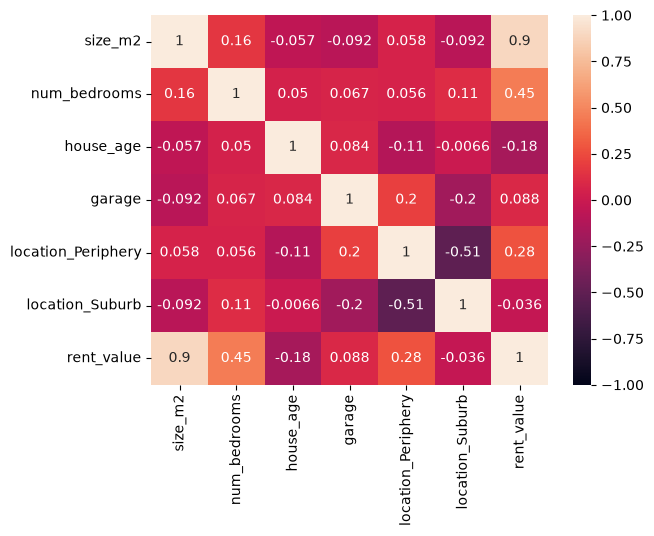

In [28]:

sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True)

In [12]:
df = df.rename(columns={
    'tamanho_m2': 'size_m2',
    'n_quartos': 'num_bedrooms',
    'idade_casa': 'house_age',
    'garagem': 'garage',
    'localizacao_Periferia': 'location_Periphery',
    'localizacao_Subúrbio': 'location_Suburb',
    'valor_aluguel': 'rent_value'
})

In [21]:
df.head()

,size_m2,num_bedrooms,house_age,garage,location_Periphery,location_Suburb,rent_value
0,106.181018,1,36.760806,0,1,0,1767.122088
1,192.607146,4,10.453581,1,1,0,3278.742397
2,159.799091,5,27.072399,1,1,0,2953.899737
3,139.798773,4,34.789220,1,0,1,2514.717108
4,73.402796,5,11.427501,0,0,1,1942.164396


In [15]:
df[['location_Periphery', 'location_Suburb']] = df[['location_Periphery', 'location_Suburb']].astype(int)

In [16]:
df.head(5)

,size_m2,num_bedrooms,house_age,garage,location_Periphery,location_Suburb,rent_value
0,106.181018,1,36.760806,0,1,0,1767.122088
1,192.607146,4,10.453581,1,1,0,3278.742397
2,159.799091,5,27.072399,1,1,0,2953.899737
3,139.798773,4,34.789220,1,0,1,2514.717108
4,73.402796,5,11.427501,0,0,1,1942.164396


<Axes: xlabel='size_m2'>

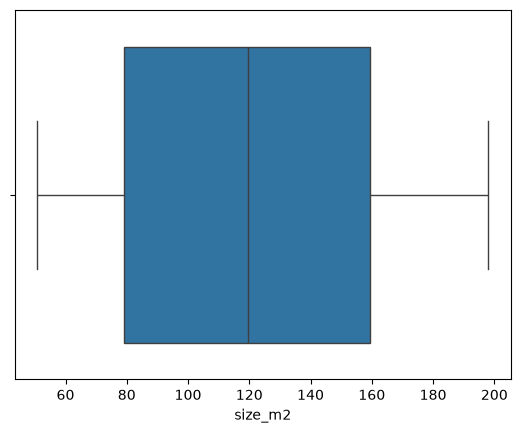

In [17]:
sns.boxplot(x=df['size_m2'])

<Axes: xlabel='rent_value'>

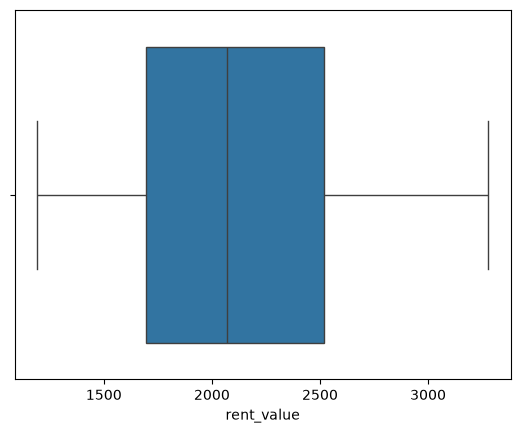

In [19]:
sns.boxplot(x=df['rent_value'])

<Axes: xlabel='house_age'>

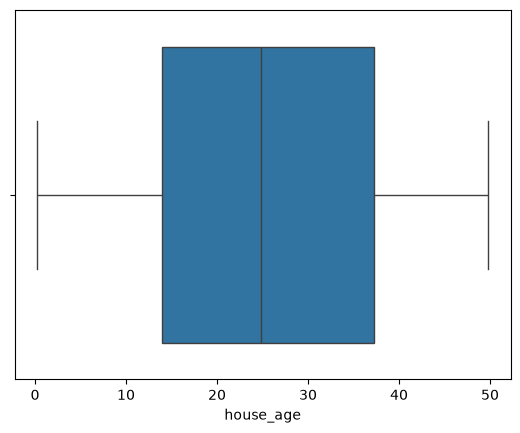

In [22]:
sns.boxplot(x=df['house_age'])

In [24]:
df['num_bedrooms'].value_counts()

num_bedrooms
4    26
1    25
3    22
5    14
2    13
Name: count, dtype: int64

In [ ]:
# No Outliers in the DataFrame

In [26]:
df.dtypes

size_m2               float64
num_bedrooms            int64
house_age             float64
garage                  int64
location_Periphery      int64
location_Suburb         int64
rent_value            float64
dtype: object

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [31]:
X = df.drop(columns=['rent_value'])
y = df['rent_value']


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)